# IRAF Aspect-Feature Mapping

In [38]:
import numpy as np
from dtaidistance import dtw as dtw_lib
from scipy.stats import spearmanr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import re

In [39]:
RQ2_DIR       = Path('../data/processed/rq2/corrected')
FEATURES_BASE = Path('../data/processed')
RQ2_DIR.mkdir(parents=True, exist_ok=True)

KORS_VIDEOS = ['028', '045', '059', '074', '091']
RAK_VIDEOS  = ['030', '047', '061', '076', '093']
ALL_VIDEOS  = KORS_VIDEOS + RAK_VIDEOS

MOVEMENTS = {
    '2a_1': {
        'label':        'sit-to-stand',
        'features_dir': 'features'
},
    '2a_2': {
        'label':        'stand-to-sit',
        'features_dir': 'features_down'
    },
}

print('KORS videos:', KORS_VIDEOS)
print('RAK  videos:', RAK_VIDEOS)
print()
for mid, info in MOVEMENTS.items():
    print(f'{mid} ({info["label"]}):')
    print(f'  features:  {info["features_dir"]}')

KORS videos: ['028', '045', '059', '074', '091']
RAK  videos: ['030', '047', '061', '076', '093']

2a_1 (sit-to-stand):
  features:  features
2a_2 (stand-to-sit):
  features:  features_down


## Step 1: Reference Sequence

SB (Fp1) is the reference participant for both movements and both conditions.

ster per condition:
- KORS: video `028`: reference for 045, 059, 074, 091
- RAK:  video `030`:  reference for 047, 061, 076, 093

In [40]:
reference = {
    'participant': 'SB (Fp1)',
    'kors_video': '028',
    'rak_video':  '030',
}

KORS_OTHERS = [v for v in KORS_VIDEOS if v != reference['kors_video']]
RAK_OTHERS  = [v for v in RAK_VIDEOS  if v != reference['rak_video']]

VIDEO_TO_MASTER = (
    {v: reference['kors_video'] for v in KORS_OTHERS} |
    {v: reference['rak_video']  for v in RAK_OTHERS}
)

print('Reference participant:', reference['participant'])
print('  KORS master:', reference['kors_video'], '-> compare against:', KORS_OTHERS)
print('  RAK  master:', reference['rak_video'],  '-> compare against:', RAK_OTHERS)

Reference participant: SB (Fp1)
  KORS master: 028 -> compare against: ['045', '059', '074', '091']
  RAK  master: 030 -> compare against: ['047', '061', '076', '093']


## Step 2: Aspect-Feature Mapping

In [41]:
EXCEL_RAK  = Path('../data/original/Final_IRAF_SAT_Rak_Bedömare sep och gemensamt.xlsx')
EXCEL_KORS = Path('../data/original/Forts_IRAF_SAT_Kors _Gemensamt.xlsx')

PHASE_MAPPING    = {'Utgångsposition': 'f1', 'Rörelsestart': 'f2', 'Rörelseutförande': 'f3'}
MOVEMENT_MAPPING = {'Sittande till stående': '2a_1', 'Stående till sittande': '2a_2'}

HEADER_ASPECTS = {
    'Förberedelsefas (fram till och med seat off)',
    'Uppresningsfas (efter seat off till upprätt stående)',
    'Fas 1 (inledande nedåtgående rörelse)',
    'Fas 2 (avslutande bakåtgående rörelse)',
}

# Participant name to Fp mapping
NAME_TO_FP = {'SB':'fp1','CF':'fp2','JN':'fp3','AL':'fp4','WL':'fp5',
              'Fp1':'fp1','Fp2':'fp2','Fp3':'fp3','Fp4':'fp4','Fp5':'fp5'}

FP_TO_KORS = {'fp1':'028','fp2':'045','fp3':'059','fp4':'074','fp5':'091'}
FP_TO_RAK  = {'fp1':'030','fp2':'047','fp3':'061','fp4':'076','fp5':'093'}

### Extract video ID from header row, or derive from participant name


In [42]:

def derive_video(header_str, condition):
    m = re.search(r'(?:Video|Film Nr?[:\s]+|film\s+)(\d+)', header_str, re.IGNORECASE)
    if m:
        return m.group(1).zfill(3)
    for name, fp in NAME_TO_FP.items():
        if name in header_str:
            return FP_TO_KORS[fp] if condition == 'KORS' else FP_TO_RAK[fp]
    return None

def read_gem(row, gem_col):
    """Read Gem_Avvikelse (0-2) directly. Numeric = rated. x/empty/NaN = excluded."""
    if gem_col is None:
        return None
    raw = row.iloc[gem_col]
    if pd.isna(raw):
        return None
    s = str(raw).strip().lower()
    if s in ('x', '', 'none', 'nan'):
        return None
    try:
        return float(raw)
    except (ValueError, TypeError):
        return None

score_rows = []

for fname, condition in [(EXCEL_KORS, 'KORS'), (EXCEL_RAK, 'RAK')]:
    xl = pd.ExcelFile(fname)
    for sheet_name, movement_id in MOVEMENT_MAPPING.items():
        if sheet_name not in xl.sheet_names:
            continue
        df = pd.read_excel(fname, sheet_name=sheet_name, header=None)

        gem_col = None
        for i, row in df.iterrows():
            for j, v in enumerate(row):
                sv = str(v) if pd.notna(v) else ''
                if 'Gem_Avvikelse' in sv and 'Ej' not in sv:
                    gem_col = j
            if gem_col is not None:
                break

        current_video  = None
        current_phase  = None
        counter        = 0
        in_block       = False

        for _, row in df.iterrows():
            r0 = str(row.iloc[0]).replace(' ', ' ').strip() if pd.notna(row.iloc[0]) else ''
            if not r0:
                continue

            if any(x in r0 for x in ['Fp', 'Försök', 'SB', 'CF', 'JN', 'AL', 'WL']):
                new_vid = derive_video(r0, condition)
                if new_vid:
                    current_video = new_vid
                    current_phase = None
                    counter       = 0
                    in_block      = True
                continue

            if r0 in PHASE_MAPPING:
                current_phase = PHASE_MAPPING[r0]
                counter = 0
                continue

            if 'Viktning' in r0 or ('Avvikelse' in r0 and 'Bäcken' not in r0 and 'Knäna' not in r0):
                continue

            if current_phase and current_video and in_block:
                counter += 1
                if r0 in HEADER_ASPECTS:
                    continue
                gem_val = read_gem(row, gem_col)
                score_rows.append({
                    'condition':     condition,
                    'video_id':      current_video,
                    'movement':      movement_id,
                    'phase':         current_phase,
                    'aspect_id':     counter,
                    'aspect_name':   r0,
                    'gem_avvikelse': gem_val,
                })

iraf_scores_df = pd.DataFrame(score_rows)
rated = iraf_scores_df[iraf_scores_df['gem_avvikelse'].notna()].reset_index(drop=True)
rated.to_csv(RQ2_DIR / 'iraf_scores.csv', index=False)

aspects_df = (
    rated[['movement', 'phase', 'aspect_id', 'aspect_name']]
    .drop_duplicates()
    .sort_values(['movement', 'phase', 'aspect_id'])
    .reset_index(drop=True)
)

print(f'iraf_scores.csv saved  ({len(rated)} rows, {rated["video_id"].nunique()} videos)')
print()
print('Ratings per video:')
print(rated.groupby(['video_id','movement']).size().unstack(fill_value=0).to_string())


iraf_scores.csv saved  (321 rows, 10 videos)

Ratings per video:
movement  2a_1  2a_2
video_id            
028         19     9
030         19    17
045         19    12
047         21    14
059         19    11
061         20    14
074         18    10
076         19    14
091         20    10
093         20    16


### Available features

In [43]:
FEATURES_BASE = Path('../data/processed')

col_lookup = {}
for d in ['features', 'features_down']:
    for csv_path in sorted((FEATURES_BASE / d).glob('*.csv')):
        fname    = csv_path.name
        movement = '2a_2' if 'down' in fname else '2a_1'
        source   = 'MoLab' if 'molab' in fname else 'SAT'
        for col in pd.read_csv(csv_path, nrows=0).columns:
            if col.lower() in ('video_id', 'video', 'index') or col.startswith('Unnamed'):
                continue
            col_lookup[(movement, col)] = {'features_dir': d, 'csv_file': fname, 'source': source}

print(f'Discovered {len(col_lookup)} feature columns across both movements')

Discovered 121 feature columns across both movements


### Expert mapping

SAT features are listed first. MoLab is added when SAT does not cover the aspect.

In [44]:
ASPECT_FEATURES = {('2a_1', 'f1', 1): [('utg_mean_left_knee_angle',
                      'SAT knee angle ~90° is the closest proxy for feet positioned directly in front of hips'),
                     ('utg_mean_right_knee_angle',
                      'SAT knee angle ~90° is the closest proxy for feet positioned directly in front of hips')],
 ('2a_1', 'f1', 2): [('utg_mean_left_knee_angle',
                      'SAT left knee flexion angle directly quantifies whether the knee exceeds the required 90° '
                      'starting position'),
                     ('utg_mean_right_knee_angle',
                      'SAT right knee flexion angle directly quantifies whether the knee exceeds the required 90° '
                      'starting position')],
 ('2a_1', 'f1', 3): [('utg_delta_knee_angle',
                      'SAT left-right knee angle difference indicates whether kneecaps are symmetrically directed '
                      'forward'),
                     ('utg_delta_knee_asymmetry',
                      'MoLab left-right knee angle difference directly quantifies kneecap alignment asymmetry')],
 ('2a_1', 'f1', 4): [('utg_mean_trunk_angle',
                      'SAT trunk sagittal angle captures pelvic orientation in the starting posture'),
                     ('utg_mean_pelvis_tilt',
                      'MoLab pelvis tilt is added because it measures slight anterior pelvic tilt more directly than '
                      'SAT')],
 ('2a_1', 'f1', 5): [('utg_delta_hip_angle',
                      'SAT left-right hip height difference serves as a proxy for frontal-plane pelvis asymmetry'),
                     ('utg_mean_pelvis_lateral',
                      'MoLab lateral pelvic tilt directly measures whether crista edges are at the same level')],
 ('2a_1', 'f1', 6): [('utg_mean_trunk_angle',
                      'SAT trunk sagittal angle reflects lumbar curvature. deviation from neutral indicates '
                      'non-neutral lordosis'),
                     ('utg_mean_pelvis_tilt',
                      'MoLab pelvis tilt confirms lumbar lordosis through the degree of anterior pelvic tilt')],
 ('2a_1', 'f1', 7): [('utg_mean_trunk_angle',
                      'SAT trunk angle captures overall sagittal spinal curvature including thoracic kyphosis'),
                     ('utg_mean_head_trunk_angle',
                      'SAT head-trunk angle reflects the combined cervico-thoracic alignment relative to the trunk '
                      'axis')],
 ('2a_1', 'f1', 8): [('utg_delta_hip_height',
                      'SAT vertical hip displacement captures how far the trunk is positioned forward over the ischial '
                      'tuberosities')],
 ('2a_1', 'f1', 9): [('forb_rms_wrist_acceleration',
                      'SAT wrist acceleration during preparation is low when arms hang passively neutral along the body without rotation')],
 ('2a_1', 'f1', 10): [('utg_mean_head_trunk_angle',
                       'SAT head-trunk angle measures whether the head is centred over the trunk longitudinal axis')],
 ('2a_1', 'f1', 11): [('utg_mean_head_trunk_angle',
                       'SAT head-trunk angle serves as a proxy for cervical lordosis via head position relative to '
                       'trunk')],

 ('2a_1', 'f3', 1): [('forb_rms_trunk_acceleration',
                      'SAT RMS trunk acceleration in the preparation phase is used as the main proxy for movement '
                      'smoothness'),
                     ('uppr_rms_trunk_acceleration',
                      'SAT RMS trunk acceleration in the rise phase complements smoothness during the upward '
                      'movement'),
                     ('forb_rms_pelvis_acc',
                      'MoLab RMS pelvis acceleration during preparation provides a 3D measure of movement smoothness')],
 ('2a_1', 'f3', 2): [('forb_delta_trunk_flexion',
                      'SAT trunk flexion range in the preparation phase quantifies the forward lean achieved before '
                      'seat-off'),
                     ('forb_max_trunk_angular_velocity',
                      'SAT peak trunk angular velocity describes the speed of trunk forward movement during '
                      'preparation')],
 ('2a_1', 'f3', 3): [('forb_trunk_hip_correlation',
                      'SAT hip-trunk trajectory correlation measures whether pelvis and trunk move forward together as '
                      'a unit'),
                     ('forb_delta_trunk_flexion',
                      'SAT trunk forward displacement confirms trunk continues moving with the pelvis during '
                      'preparation'),
                     ('forb_delta_pelvis_tilt',
                      'MoLab pelvic tilt change confirms pelvis continues moving forward together with the trunk'),
                     ('forb_peak_pelvis_gyro',
                      'MoLab peak pelvis angular velocity captures the rotational intensity of pelvic forward movement')],
 ('2a_1', 'f3', 4): [('forb_mean_head_trunk_angle',
                      'SAT head-trunk angle measures whether the head stays aligned with the trunk longitudinal axis '
                      'during movement')],
 ('2a_1', 'f3', 5): [('forb_rms_wrist_acceleration',
                      'SAT wrist acceleration reflects arm activity. low values indicate arms follow passively without '
                      'active propulsion')],
 ('2a_1', 'f3', 6): [('forb_delta_trunk_flexion',
                      'SAT trunk flexion range quantifies whether sufficient forward reach is achieved before '
                      'seat-off'),
                     ('forb_max_trunk_angular_velocity',
                      'SAT peak trunk angular velocity captures whether trunk moves with adequate momentum forward')],
 ('2a_1', 'f3', 7): [('uppr_total_knee_extension',
                      'SAT total knee extension range measures whether the knee reaches full straightening during the '
                      'rise phase'),
                     ('uppr_total_hip_extension',
                      'SAT total hip extension range measures whether the hip reaches full straightening during the '
                      'rise phase'),
                     ('uppr_peak_shank_gyro',
                      'MoLab shank angular velocity directly measures tibial forward angular movement during rise')],
 ('2a_1', 'f3', 8): [('uppr_total_knee_extension',
                      'SAT knee extension range captures the forward-upward tibial movement required for full knee '
                      'straightening'),
                     ('uppr_peak_knee_extension_velocity',
                      'SAT peak knee extension velocity quantifies the speed of tibial forward displacement during '
                      'rise'),
                     ('uppr_peak_shank_gyro',
                      'MoLab shank angular velocity directly measures tibial forward angular movement speed')],
 ('2a_1', 'f3', 9): [('uppr_total_knee_extension',
                      'SAT knee extension range confirms full knee straightening toward neutral standing position'),
                     ('uppr_total_hip_extension',
                      'SAT hip extension range confirms full hip straightening toward neutral standing position')],
 ('2a_1', 'f3', 10): [('uppr_trunk_reextension_angle',
                       'SAT trunk re-extension angle directly quantifies how close the trunk returns to the upright '
                       'neutral standing position')],
 ('2a_1', 'f3', 11): [('forb_mean_head_trunk_angle',
                       'SAT head-trunk angle is the best available proxy for whether neck and shoulders follow the '
                       'trunk movement')],
 ('2a_1', 'f3', 12): [('forb_rms_wrist_acceleration',
                       'SAT wrist acceleration captures whether arms follow the movement passively throughout the '
                       'rise')],
 ('2a_2', 'f1', 1): [('utg_stance_to_hip_ratio',
                      'SAT stance width normalised to hip width measures whether feet are placed parallel and '
                      'symmetrically')],
 ('2a_2', 'f1', 2): [('utg_stance_width',
                      'SAT absolute stance width measures foot placement distance relative to hip width'),
                     ('utg_stance_to_hip_ratio',
                      'SAT hip-normalised stance ratio confirms feet are positioned directly under the hip joints')],
 ('2a_2', 'f1', 3): [('utg_hip_asym',
                      'SAT hip asymmetry index serves as a proxy for medial-lateral weight distribution between feet'),
                     ('utg_mean_pelvis_lateral',
                      'MoLab lateral pelvic tilt captures medial-lateral load distribution between feet')],
 ('2a_2', 'f1', 4): [('utg_knee_asym',
                      'SAT knee asymmetry measures left-right knee alignment. neutral alignment points kneecaps toward '
                      'middle toes'),
                     ('utg_delta_knee_angle',
                      'SAT left-right knee angle difference captures bilateral kneecap direction asymmetry')],
 ('2a_2', 'f1', 5): [('utg_mean_left_knee_angle',
                      'SAT left knee flexion angle confirms the required semi-flexed starting position'),
                     ('utg_mean_right_knee_angle',
                      'SAT right knee flexion angle confirms the required semi-flexed starting position'),
                     ('utg_mean_knee_forward',
                      'SAT mean knee forward position captures the anterior tibial inclination in the semi-flexed '
                      'stance')],
 ('2a_2', 'f1', 6): [('utg_mean_trunk_angle',
                      'SAT trunk sagittal angle captures pelvis orientation in the starting posture'),
                     ('utg_mean_pelvis_tilt',
                      'MoLab pelvis tilt is added because it measures slight anterior pelvic tilt more directly than '
                      'SAT')],
 ('2a_2', 'f1', 7): [('utg_mean_pelvis_lateral',
                      'MoLab lateral pelvic tilt directly measures SIAS symmetry in the frontal plane. no SAT feature '
                      'covers this')],
 ('2a_2', 'f1', 8): [('utg_mean_trunk_angle',
                      'SAT trunk sagittal angle reflects lumbar curvature. deviations indicate hyper- or hypolordosis'),
                     ('utg_mean_pelvis_tilt',
                      'MoLab pelvis tilt is added because lumbar lordosis cannot be inferred reliably from SAT alone')],
 ('2a_2', 'f1', 9): [('utg_mean_trunk_angle',
                      'SAT overall trunk sagittal angle captures thoracic spinal curvature in the sagittal plane'),
                     ('utg_mean_head_trunk_angle',
                      'SAT head-trunk angle reflects the upper thoracic and cervical contribution to kyphosis')],
 ('2a_2', 'f1', 10): [('utg_shoulder_asym',
                       'SAT shoulder asymmetry measures horizontal shoulder level, indicating thoracic rotation or '
                       'scoliosis'),
                      ('utg_mean_pelvis_lateral',
                       'MoLab lateral pelvic tilt complements shoulder asymmetry to capture overall frontal-plane '
                       'symmetry')],
 ('2a_2', 'f1', 11): [('utg_mean_head_trunk_angle',
                       'SAT head-trunk angle measures whether the head is symmetrically positioned directly above the '
                       'trunk')],
 ('2a_2', 'f1', 12): [('utg_mean_head_trunk_angle',
                       'SAT head-trunk angle serves as an indirect measure of cervical lordosis via head position '
                       'relative to trunk')],
 ('2a_2', 'f1', 13): [('utg_shoulder_asym',
                       'SAT shoulder asymmetry directly quantifies whether shoulders are level and symmetric')],
 ('2a_2', 'f1', 14): [('bak_rms_wrist_acceleration',
                       'SAT wrist acceleration during descent is low when upper arms remain neutral along the body without active rotation')],
 ('2a_2', 'f1', 15): [('utg_mean_trunk_angle',
                       'SAT trunk sagittal angle confirms trunk is positioned upright and aligned over pelvis'),
                      ('utg_mean_pelvis_tilt',
                       'MoLab pelvis tilt confirms neutral pelvis position under the trunk in sagittal plane')],

 ('2a_2', 'f3', 1): [('ned_ROM_trunk',
                      'SAT trunk ROM in fas 1 quantifies the forward trunk lean during the initial descent phase'),
                     ('ned_ROM_hip',
                      'SAT hip flexion ROM in fas 1 measures the degree of hip bending in the initial descent'),
                     ('ned_phase_duration',
                      'SAT fas 1 duration captures the temporal control of the initial lowering phase')],
 ('2a_2', 'f3', 2): [('ned_ROM_trunk',
                      'SAT trunk ROM confirms the total forward lean range during the continued descent'),
                     ('ned_ROM_hip',
                      'SAT hip flexion ROM directly quantifies continued hip bending during the descent')],
 ('2a_2', 'f3', 3): [('ned_ROM_knee',
                      'SAT knee flexion ROM measures how much the knees continue to bend and advance forward'),
                     ('ned_mean_knee_forward',
                      'SAT mean knee forward position quantifies the horizontal knee displacement over the toes')],
 ('2a_2', 'f3', 4): [('ned_knee_asym',
                      'SAT knee asymmetry measures whether both knees maintain symmetric forward direction in fas 1'),
                     ('ned_knee_angle_diff',
                      'MoLab left-right knee angle difference directly quantifies kneecap alignment toward the middle '
                      'toe'),
                     ('ned_pelvis_lateral',
                      'MoLab lateral pelvis tilt in fas 1 reflects lower-limb frontal-plane alignment')],
 ('2a_2', 'f3', 5): [('ned_peak_pelvis_velocity_y',
                      'SAT peak vertical pelvis velocity captures the maximum downward speed. high values indicate '
                      'uncontrolled drop'),
                     ('ned_rms_pelvis_acc_y',
                      'SAT RMS vertical pelvis acceleration quantifies smoothness of descent. high values indicate '
                      'jerkiness')],
 ('2a_2', 'f3', 6): [('bak_pelvis_backward_displacement',
                      'SAT posterior pelvis displacement measures the backward pelvis shift in the final lowering '
                      'phase'),
                     ('bak_pelvis_descent', 'SAT vertical pelvis descent quantifies the downward movement in fas 2'),
                     ('bak_phase_duration',
                      'SAT fas 2 duration captures the temporal control of the final descent phase')],
 ('2a_2', 'f3', 7): [('bak_pelvis_backward_displacement',
                      'SAT posterior pelvis displacement quantifies the controlled backward-downward pelvis '
                      'trajectory'),
                     ('bak_pelvis_descent',
                      'SAT vertical pelvis descent confirms controlled lowering toward the seat'),
                     ('bak_rms_pelvis_acc',
                      'MoLab pelvis acceleration is added as a compact 3D control measure for the final '
                      'backward-downward transfer')],
 ('2a_2', 'f3', 8): [('bak_knee_asym',
                      'SAT knee asymmetry measures whether knees remain directed toward the middle toe during final '
                      'descent')],
 ('2a_2', 'f3', 9): [('bak_rms_wrist_acceleration',
                      'SAT wrist acceleration measures whether hands and arms follow passively without active midline '
                      'crossing')]}

total_pairs = sum(len(v) for v in ASPECT_FEATURES.values())
print(f'ASPECT_FEATURES: {len(ASPECT_FEATURES)} aspects defined, {total_pairs} feature-aspect pairs')
print(f'  2a_1: {sum(1 for k in ASPECT_FEATURES if k[0]=="2a_1")} aspects')
print(f'  2a_2: {sum(1 for k in ASPECT_FEATURES if k[0]=="2a_2")} aspects')

ASPECT_FEATURES: 47 aspects defined, 87 feature-aspect pairs
  2a_1: 23 aspects
  2a_2: 24 aspects


In [45]:
fa_rows = []
for (movement, phase, aspect_id), entries in ASPECT_FEATURES.items():
    for col, rationale in entries:
        info = col_lookup.get((movement, col))
        if info is None:
            print(f'WARNING: ({movement}, {col}) not in col_lookup')
            continue
        fa_rows.append({
            'movement':       movement,
            'phase':          phase,
            'aspect_id':      aspect_id,
            'features_dir':   info['features_dir'],
            'csv_file':       info['csv_file'],
            'feature_column': col,
            'source':         info['source'],
            'rationale':      rationale,
        })

fa_df      = pd.DataFrame(fa_rows)
mapping_df = fa_df.merge(aspects_df, on=['movement', 'phase', 'aspect_id'], how='inner')
MAPPING_COLS = ['movement','phase','aspect_id','aspect_name',
                'features_dir','csv_file','feature_column','source','rationale']
mapping_df = mapping_df[MAPPING_COLS]
mapping_df.to_csv(RQ2_DIR / 'aspect_feature_mapping.csv', index=False)

n_rated_sts   = mapping_df[mapping_df.movement=='2a_1'][['phase','aspect_id']].drop_duplicates().shape[0]
n_rated_stsit = mapping_df[mapping_df.movement=='2a_2'][['phase','aspect_id']].drop_duplicates().shape[0]
n_defined_sts   = sum(1 for k in ASPECT_FEATURES if k[0]=='2a_1')
n_defined_stsit = sum(1 for k in ASPECT_FEATURES if k[0]=='2a_2')
print(f'aspect_feature_mapping.csv saved  ({len(mapping_df)} rows)')
print(f'  STS   rated/mapped: {n_rated_sts}/{n_defined_sts} aspects')
print(f'  StSit rated/mapped: {n_rated_stsit}/{n_defined_stsit} aspects')

aspect_feature_mapping.csv saved  (67 rows)
  STS   rated/mapped: 20/23 aspects
  StSit rated/mapped: 18/24 aspects


In [46]:
def compact_table(df):
    return (
        df.groupby(['phase','aspect_id','aspect_name'], sort=False)
        .agg(
            candidate_features=('feature_column', lambda x: '/ '.join(x)),
            data_source=('source', lambda x: '/ '.join(x.unique())),
            rationale=('rationale', lambda x: '/ '.join(x.unique())),
        )
        .reset_index()
        .rename(columns={'aspect_name': 'aspect'})
        [['phase','aspect','candidate_features','data_source','rationale']]
    )

sts_table   = compact_table(mapping_df[mapping_df.movement == '2a_1'])
stsit_table = compact_table(mapping_df[mapping_df.movement == '2a_2'])

print('Sit-to-Stand (2a_1) - Aspect-Feature Mapping')
display(sts_table)

print('Stand-to-Sit (2a_2) - Aspect-Feature Mapping')

stsit_table

Sit-to-Stand (2a_1) - Aspect-Feature Mapping


,phase,aspect,candidate_features,data_source,rationale
0,f1,Fötterna rakt framför höftlederna,utg_mean_left_knee_angle/ utg_mean_right_knee_...,SAT,SAT knee angle ~90° is the closest proxy for f...
1,f1,Knä flex >90gr,utg_mean_left_knee_angle/ utg_mean_right_knee_...,SAT,SAT left knee flexion angle directly quantifie...
2,f1,Knäskålarna riktade rakt fram,utg_delta_knee_angle/ utg_delta_knee_asymmetry,SAT/ MoLab,SAT left-right knee angle difference indicates...
3,f1,Bäcken i neutralposition (lätt framåttippat),utg_mean_trunk_angle/ utg_mean_pelvis_tilt,SAT/ MoLab,SAT trunk sagittal angle captures pelvic orien...
4,f1,Ländrygg i neutral ländlordos,utg_mean_trunk_angle/ utg_mean_pelvis_tilt,SAT/ MoLab,SAT trunk sagittal angle reflects lumbar curva...
5,f1,Bröstrygg i neutral thorakalkyfos,utg_mean_trunk_angle/ utg_mean_head_trunk_angle,SAT,SAT trunk angle captures overall sagittal spin...
6,f1,Hela bålen strax framför sittbensknölarna,utg_delta_hip_height,SAT,SAT vertical hip displacement captures how far...
7,f1,Överarmar neutralt längs med bålen utan rotation,forb_rms_wrist_acceleration,SAT,SAT wrist acceleration during preparation is l...
8,f1,Huvudet positionerat över bålen,utg_mean_head_trunk_angle,SAT,SAT head-trunk angle measures whether the head...
9,f1,Nacke i neutral cervikallordos,utg_mean_head_trunk_angle,SAT,SAT head-trunk angle serves as a proxy for cer...


Stand-to-Sit (2a_2) - Aspect-Feature Mapping


,phase,aspect,candidate_features,data_source,rationale
0,f1,"Står med fötterna parallellt, riktade rakt fram",utg_stance_to_hip_ratio,SAT,SAT stance width normalised to hip width measu...
1,f1,Står med fötterna rakt under höftlederna,utg_stance_width/ utg_stance_to_hip_ratio,SAT,SAT absolute stance width measures foot placem...
2,f1,Knäskålarna riktade mot mellersta tån,utg_knee_asym/ utg_delta_knee_angle,SAT,SAT knee asymmetry measures left-right knee al...
3,f1,Knäna neutralt semiflekterade,utg_mean_left_knee_angle/ utg_mean_right_knee_...,SAT,SAT left knee flexion angle confirms the requi...
4,f1,Bäckenet neutralt framåttippat i sagittalplan,utg_mean_trunk_angle/ utg_mean_pelvis_tilt,SAT/ MoLab,SAT trunk sagittal angle captures pelvis orien...
5,f1,Thorakalrygg i neutral kyfos i sagittalplan,utg_mean_trunk_angle/ utg_mean_head_trunk_angle,SAT,SAT overall trunk sagittal angle captures thor...
6,f1,Huvudet symmetrisk position rakt ovanför bålen,utg_mean_head_trunk_angle,SAT,SAT head-trunk angle measures whether the head...
7,f1,Cervikalrygg i neutral lordos i sagittalplan,utg_mean_head_trunk_angle,SAT,SAT head-trunk angle serves as an indirect mea...
8,f1,Axlarna symmetriska och i samma nivå,utg_shoulder_asym,SAT,SAT shoulder asymmetry directly quantifies whe...
9,f1,Överarmarna längs med bålen,bak_rms_wrist_acceleration,SAT,SAT wrist acceleration during descent is low w...


In [47]:
sts_table.to_csv(RQ2_DIR / 'sit_to_stand_aspect_mapping.csv', index=False)
stsit_table.to_csv(RQ2_DIR / 'stand_to_sit_aspect_mapping.csv', index=False)
print('Saved to', RQ2_DIR)
for f in ['aspect_feature_mapping.csv',
          'sit_to_stand_aspect_mapping.csv', 'stand_to_sit_aspect_mapping.csv']:
    print(f'  {f}')


Saved to ../data/processed/rq2/corrected
  aspect_feature_mapping.csv
  sit_to_stand_aspect_mapping.csv
  stand_to_sit_aspect_mapping.csv


### Compute aspect scores

- Min-max normalize each feature within condition (KORS and RAK separately)
- Then average features per aspect.

In [48]:
feature_data = {}
for _, row in mapping_df[['features_dir', 'csv_file']].drop_duplicates().iterrows():
    path = FEATURES_BASE / row['features_dir'] / row['csv_file']
    if not path.exists():
        print(f'WARNING: file not found: {path}')
        continue
    df = pd.read_csv(path)
    id_col = next((c for c in df.columns if c.lower() in ('video', 'video_id')), None)
    if id_col:
        df = df.set_index(id_col)
        df.index = df.index.map(lambda x: str(int(float(x))).zfill(3))
    df = df.loc[df.index.intersection(ALL_VIDEOS)]
    feature_data[(row['features_dir'], row['csv_file'])] = df

all_csvs  = {(d, p.name) for d in ['features','features_down'] for p in sorted((FEATURES_BASE / d).glob('*.csv'))}
used_csvs = set(tuple(r) for _, r in mapping_df[['features_dir','csv_file']].drop_duplicates().iterrows())
unused    = all_csvs - used_csvs
if unused:
    print(f'CSVs not used in mapping: {sorted(unused)}')
print(f'Loaded {len(feature_data)} / {len(all_csvs)} feature files  ({len(ALL_VIDEOS)} videos)')

Loaded 12 / 12 feature files  (10 videos)


In [49]:
def minmax(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0.0
    return (series - mn) / (mx - mn)

score_rows = []
for (mvmt, phase, aid), group in mapping_df.groupby(['movement', 'phase', 'aspect_id']):
    normalized = []
    for _, feat_row in group.iterrows():
        col = feat_row['feature_column']
        df  = feature_data.get((feat_row['features_dir'], feat_row['csv_file']))
        if df is None or col not in df.columns:
            print(f'WARNING: {col} not found in {feat_row["csv_file"]}')
            continue
        kors_vids = [v for v in KORS_VIDEOS if v in df.index]
        rak_vids  = [v for v in RAK_VIDEOS  if v in df.index]
        parts = []
        if kors_vids:
            parts.append(minmax(df.loc[kors_vids, col]))
        if rak_vids:
            parts.append(minmax(df.loc[rak_vids,  col]))
        if parts:
            normalized.append(pd.concat(parts))
    if not normalized:
        continue
    aspect_score = pd.concat(normalized, axis=1).mean(axis=1)
    for video_id, score in aspect_score.items():
        score_rows.append({
            'movement': mvmt, 'phase': phase, 'aspect_id': aid,
            'video_id': video_id, 'aspect_score': round(score, 4),
        })
print(f'Computed {len(score_rows)} score rows  ({len(set((r["movement"],r["phase"],r["aspect_id"]) for r in score_rows))} aspects, {len(set(r["video_id"] for r in score_rows))} videos)')

Computed 380 score rows  (38 aspects, 10 videos)


In [50]:
SCORE_COLS = ['movement', 'phase', 'aspect_id', 'video_id', 'aspect_score']
aspect_scores_df = pd.DataFrame(score_rows, columns=SCORE_COLS)
aspect_scores_df = aspect_scores_df.merge(
    aspects_df[['movement', 'phase', 'aspect_id', 'aspect_name']],
    on=['movement', 'phase', 'aspect_id'], how='left'
)

aspect_scores_df.to_csv(RQ2_DIR / 'aspect_scores.csv', index=False)

n_aspects = aspect_scores_df[['movement','phase','aspect_id']].drop_duplicates().shape[0]
n_videos  = aspect_scores_df['video_id'].nunique()
print(f'aspect_scores.csv saved  ({len(aspect_scores_df)} rows, {n_aspects} aspects, {n_videos} videos)')
aspect_scores_df.head(20)


aspect_scores.csv saved  (380 rows, 38 aspects, 10 videos)


,movement,phase,aspect_id,video_id,aspect_score,aspect_name
0,2a_1,f1,1,028,0.2609,Fötterna rakt framför höftlederna
1,2a_1,f1,1,045,0.0206,Fötterna rakt framför höftlederna
2,2a_1,f1,1,059,0.1370,Fötterna rakt framför höftlederna
3,2a_1,f1,1,074,1.0000,Fötterna rakt framför höftlederna
4,2a_1,f1,1,091,0.3329,Fötterna rakt framför höftlederna
5,2a_1,f1,1,030,0.9817,Fötterna rakt framför höftlederna
6,2a_1,f1,1,047,0.7838,Fötterna rakt framför höftlederna
7,2a_1,f1,1,061,0.6643,Fötterna rakt framför höftlederna
8,2a_1,f1,1,076,0.8321,Fötterna rakt framför höftlederna
9,2a_1,f1,1,093,0.0000,Fötterna rakt framför höftlederna


In [51]:
for mvmt, label in [('2a_1', 'sit_to_stand'), ('2a_2', 'stand_to_sit')]:
    sub = aspect_scores_df[aspect_scores_df.movement == mvmt].copy()
    pivot = sub.pivot_table(
        index=['phase', 'aspect_id', 'aspect_name'],
        columns='video_id',
        values='aspect_score'
    )
    pivot.columns.name = None
    pivot = pivot.reset_index()
    out = RQ2_DIR / f'{label}_aspect_scores_normalized.csv'
    pivot.to_csv(out, index=False)
    print(f'{out.name}  ({pivot.shape[0]} aspects x {pivot.shape[1]-3} videos)')
    pivot


sit_to_stand_aspect_scores_normalized.csv  (20 aspects x 10 videos)
stand_to_sit_aspect_scores_normalized.csv  (18 aspects x 10 videos)


## Step 3: Phase Alignment Setup

Load raw trajectories for all videos. Trajectories are extracted per phase window using TIME_DICT.

**Why DTW instead of linear interpolation:**

- **No fake frames**: interpolation creates intermediate states that do not exist in the data. DTW compares only actual measured frames.
- **Preserves motion nature**: human motion accelerates and decelerates. Interpolation forces a constant-speed assumption. DTW handles this naturally.
- **Tempo-independent**: a fast repetition (60 frames) and a slow one (100 frames) are compared directly - DTW stretches time, not the signal.

In [52]:
TIME_DICT = {
    '028': (9.90, 10.44, 11.20, 11.77),
    '030': (5.80,  6.12,  6.80,  7.63),
    '045': (6.54,  6.74,  7.36,  7.98),
    '047': (7.03,  7.36,  7.88,  8.80),
    '059': (6.65,  6.90,  8.10,  9.11),
    '061': (7.00,  7.40,  8.20,  9.00),
    '074': (6.07,  6.22,  6.80,  7.27),
    '076': (5.20,  5.80,  6.34,  7.20),
    '091': (6.39,  6.52,  7.14,  7.61),
    '093': (5.86,  6.22,  6.74,  7.50),
}

DOWN_TIME_DICT = {
    '028': (11.87, 11.90, 12.57, 12.82),
    '030': ( 8.07,  9.70, 10.64, 11.16),
    '045': ( 7.94,  7.96,  8.74,  9.26),
    '047': ( 9.20, 10.14, 11.10, 11.70),
    '059': ( 9.11,  9.18, 10.37, 11.06),
    '061': (10.57, 10.88, 12.26, 13.00),
    '074': ( 7.27,  7.30,  7.88,  8.14),
    '076': ( 8.27,  8.72,  9.73, 10.32),
    '091': ( 7.56,  7.58,  8.09,  8.18),
    '093': ( 8.50,  9.24, 10.08, 10.74),
}

KP_DIR      = FEATURES_BASE.parent / 'processed' / 'keypoints_combined'
KP_DOWN_DIR = FEATURES_BASE.parent / 'processed' / 'keypoints_combined_down'
ML_DIR      = FEATURES_BASE.parent / 'processed' / 'molab_cropped'
ML_DOWN_DIR = FEATURES_BASE.parent / 'processed' / 'molab_cropped_down'

def find_kp_file(vid4, directory):
    matches = list(directory.glob(f'*_{vid4}_D.csv'))
    return matches[0] if matches else None

print('TIME_DICT loaded:', len(TIME_DICT), 'videos')
print('DOWN_TIME_DICT loaded:', len(DOWN_TIME_DICT), 'videos')

TIME_DICT loaded: 10 videos
DOWN_TIME_DICT loaded: 10 videos


In [53]:
def angle_2d(ax, ay, bx, by, cx, cy):
    v1x,v1y = ax-bx, ay-by
    v2x,v2y = cx-bx, cy-by
    cos_a = (v1x*v2x+v1y*v2y)/(np.sqrt(v1x**2+v1y**2)*np.sqrt(v2x**2+v2y**2)+1e-8)
    return np.degrees(np.arccos(np.clip(cos_a,-1,1)))

print('angle_2d defined')

angle_2d defined


In [54]:
def sat_trajectories(kp):
    sh_x = (kp['left_shoulder_x']+kp['right_shoulder_x'])/2
    sh_y = (kp['left_shoulder_y']+kp['right_shoulder_y'])/2
    hp_x = (kp['left_hip_x']+kp['right_hip_x'])/2
    hp_y = (kp['left_hip_y']+kp['right_hip_y'])/2
    trunk = np.degrees(np.arctan2((sh_x-hp_x).values, -(sh_y-hp_y).values))
    trunk_vel = np.gradient(trunk)
    wx = (kp['left_wrist_x']+kp['right_wrist_x'])/2
    wy = (kp['left_wrist_y']+kp['right_wrist_y'])/2
    wvx,wvy = np.gradient(wx.values),np.gradient(wy.values)
    hip_w = np.sqrt((kp['left_hip_x']-kp['right_hip_x'])**2+(kp['left_hip_y']-kp['right_hip_y'])**2).values
    stance = np.sqrt((kp['left_ankle_x']-kp['right_ankle_x'])**2+(kp['left_ankle_y']-kp['right_ankle_y'])**2).values
    return {
        'time':            kp['time'].values,
        'knee_angle_L':    angle_2d(kp['left_hip_x'],kp['left_hip_y'],kp['left_knee_x'],kp['left_knee_y'],kp['left_ankle_x'],kp['left_ankle_y']),
        'knee_angle_R':    angle_2d(kp['right_hip_x'],kp['right_hip_y'],kp['right_knee_x'],kp['right_knee_y'],kp['right_ankle_x'],kp['right_ankle_y']),
        'knee_angle_diff': angle_2d(kp['left_hip_x'],kp['left_hip_y'],kp['left_knee_x'],kp['left_knee_y'],kp['left_ankle_x'],kp['left_ankle_y']) - angle_2d(kp['right_hip_x'],kp['right_hip_y'],kp['right_knee_x'],kp['right_knee_y'],kp['right_ankle_x'],kp['right_ankle_y']),
        'trunk_angle':     trunk,
        'trunk_vel':       np.abs(trunk_vel),
        'trunk_acc':       np.abs(np.gradient(trunk_vel)),
        'head_trunk_angle':angle_2d(kp['nose_x'],kp['nose_y'],sh_x,sh_y,hp_x,hp_y),
        'hip_height':      hp_y.values,
        'hip_asym':        (kp['left_hip_y']-kp['right_hip_y']).values,
        'knee_asym':       (kp['left_knee_x']-kp['right_knee_x']).values,
        'knee_forward_L':  (kp['left_knee_x']-kp['left_ankle_x']).values,
        'shoulder_asym':   (kp['left_shoulder_y']-kp['right_shoulder_y']).values,
        'stance_width':    stance,
        'stance_ratio':    stance/(hip_w+1e-8),
        'hip_angle_L':     angle_2d(kp['left_shoulder_x'],kp['left_shoulder_y'],kp['left_hip_x'],kp['left_hip_y'],kp['left_knee_x'],kp['left_knee_y']),
        'wrist_acc':       np.sqrt(np.gradient(wvx)**2+np.gradient(wvy)**2),
    }

print('sat_trajectories defined')

sat_trajectories defined


In [55]:
def molab_trajectories(ml):
    return {
        'time':           ml['video_time'].values,
        'pelvis_tilt':    ml['JointAngle/pelvis_X'].values,
        'pelvis_lateral': ml['JointAngle/pelvis_Y'].values,
        'pelvis_gyro':    np.sqrt(ml['SegmentGyro/pelvis_X']**2+ml['SegmentGyro/pelvis_Y']**2+ml['SegmentGyro/pelvis_Z']**2).values,
        'pelvis_acc':     np.sqrt(ml['SegmentAcc/pelvis_X']**2+ml['SegmentAcc/pelvis_Y']**2+ml['SegmentAcc/pelvis_Z']**2).values,
    }

print('molab_trajectories defined')

molab_trajectories defined


In [56]:
FEAT_TO_TRAJ = {
    'utg_mean_left_knee_angle':          ('knee_angle_L',    'SAT'),
    'mean_right_knee_angle':         ('knee_angle_R',    'SAT'),
    'delta_knee_angle':              ('knee_angle_diff', 'SAT'),
    'mean_trunk_angle':              ('trunk_angle',     'SAT'),
    'delta_trunk_flexion':           ('trunk_angle',     'SAT'),
    'forb_delta_trunk_flexion':      ('trunk_angle',     'SAT'),
    'forb_rms_trunk_acceleration':   ('trunk_acc',       'SAT'),
    'uppr_rms_trunk_acceleration':   ('trunk_acc',       'SAT'),
    'forb_max_trunk_angular_velocity':('trunk_vel',      'SAT'),
    'forb_trunk_hip_correlation':    ('trunk_angle',     'SAT'),
    'forb_mean_head_trunk_angle':    ('head_trunk_angle','SAT'),
    'mean_head_trunk_angle':         ('head_trunk_angle','SAT'),
    'delta_hip_height':              ('hip_height',      'SAT'),
    'delta_hip_angle':               ('hip_asym',        'SAT'),
    'hip_asym':                      ('hip_asym',        'SAT'),
    'knee_asym':                     ('knee_asym',       'SAT'),
    'shoulder_asym':                 ('shoulder_asym',   'SAT'),
    'stance_width':                  ('stance_width',    'SAT'),
    'stance_to_hip_ratio':           ('stance_ratio',    'SAT'),
    'mean_knee_forward':             ('knee_forward_L',  'SAT'),
    'ROM_hip':                       ('hip_angle_L',     'SAT'),
    'ned_ROM_trunk':                ('trunk_angle',     'SAT'),
    'fas2_ROM_trunk':                ('trunk_angle',     'SAT'),
    'forb_rms_wrist_acceleration':   ('wrist_acc',       'SAT'),
    'uppr_rms_wrist_acceleration':   ('wrist_acc',       'SAT'),
    'fas2_rms_wrist_acceleration':   ('wrist_acc',       'SAT'),
    'mean_pelvis_tilt':              ('pelvis_tilt',     'MoLab'),
    'delta_pelvis_tilt':             ('pelvis_tilt',     'MoLab'),
    'forb_delta_pelvis_tilt':        ('pelvis_tilt',     'MoLab'),
    'mean_pelvis_lateral':           ('pelvis_lateral',  'MoLab'),
    'delta_knee_asymmetry':          ('pelvis_lateral',  'MoLab'),
    'forb_rms_pelvis_acc':           ('pelvis_acc',      'MoLab'),
    'forb_peak_pelvis_gyro':         ('pelvis_gyro',     'MoLab'),
}

print(f'FEAT_TO_TRAJ defined  ({len(FEAT_TO_TRAJ)} features mapped)')

FEAT_TO_TRAJ defined  (33 features mapped)


In [57]:
def get_window(feat_col, phase, times, movement):
    if movement == '2a_1':
        t0,t1,t2,t3 = times
        if phase == 'f1':  return None
        if feat_col.startswith('forb_'): return (t1, t2)
        if feat_col.startswith('uppr_'): return (t2, t3)
        return (t1, t3)
    else:
        t0,t1,t2,t3 = times
        if phase == 'f1':  return None
        if feat_col.startswith('ned_'): return (t1, t2)
        if feat_col.startswith('bak_'): return (t2, t3)
        return (t1, t3)



def extract_signal(traj_dict, traj_name, t_start, t_end):
    t   = traj_dict['time']
    sig = traj_dict[traj_name]
    mask = (t >= t_start) & (t <= t_end)
    if mask.sum() < 2:
        return None
    arr = sig[mask]
    if hasattr(arr, 'to_numpy'):
        arr = arr.to_numpy()
    return np.ascontiguousarray(arr, dtype=np.float64)

def dtw_align(sig_vid, sig_master):
    path = dtw_lib.warping_path(sig_vid, sig_master)
    aligned_vid    = np.array([sig_vid[i]    for i, j in path])
    aligned_master = np.array([sig_master[j] for i, j in path])
    return aligned_vid, aligned_master

print('get_window, extract_signal and dtw_align defined')

get_window, extract_signal and dtw_align defined


In [58]:
raw_kp  = {}
raw_kp2 = {}
raw_ml  = {}
raw_ml2 = {}

for vid in ALL_VIDEOS:
    vid4 = vid.zfill(4)
    f = find_kp_file(vid4, KP_DIR)
    if f: raw_kp[vid]  = sat_trajectories(pd.read_csv(f))
    f = find_kp_file(vid4, KP_DOWN_DIR)
    if f: raw_kp2[vid] = sat_trajectories(pd.read_csv(f))
    f = ML_DIR / f'0{vid}_molab.csv'
    if f.exists(): raw_ml[vid]  = molab_trajectories(pd.read_csv(f))
    f = ML_DOWN_DIR / f'0{vid}_molab.csv'
    if f.exists(): raw_ml2[vid] = molab_trajectories(pd.read_csv(f))

print(f'Loaded: kp={len(raw_kp)}  kp_down={len(raw_kp2)}  ml={len(raw_ml)}  ml_down={len(raw_ml2)}')

Loaded: kp=10  kp_down=10  ml=10  ml_down=10


## Step 4: Feature-Level Deviations from Master

For each feature, within each phase, for each participant: compute MAE against the master (SB).

- **f1:** scalar `|participant - master|`, no time-series available
- **f2, forb, uppr, fas1, fas2:** DTW-align participant trajectory to master, compute MAE

Master: KORS = 028, RAK = 030. Master deviation = 0.

In [59]:
dev_rows = []
scalar_f1 = 0

for _, feat_row in mapping_df.iterrows():
    col        = feat_row['feature_column']
    mvmt       = feat_row['movement']
    phase      = feat_row['phase']
    times_dict = TIME_DICT if mvmt == '2a_1' else DOWN_TIME_DICT
    kp_data    = raw_kp  if mvmt == '2a_1' else raw_kp2
    ml_data    = raw_ml  if mvmt == '2a_1' else raw_ml2
    traj_info  = FEAT_TO_TRAJ.get(col)

    for vid in ALL_VIDEOS:
        master       = VIDEO_TO_MASTER.get(vid, vid)
        times_vid    = times_dict.get(vid)
        times_master = times_dict.get(master)
        if times_vid is None or times_master is None:
            continue

        window_vid    = get_window(col, phase, times_vid,    mvmt)
        window_master = get_window(col, phase, times_master, mvmt)

        if window_vid is None or traj_info is None:
            df_feat = feature_data.get((feat_row['features_dir'], feat_row['csv_file']))
            if df_feat is not None and col in df_feat.columns and vid in df_feat.index and master in df_feat.index:
                deviation = abs(float(df_feat.loc[vid, col]) - float(df_feat.loc[master, col]))
                scalar_f1 += 1
            else:
                continue
        else:
            traj_name, src = traj_info
            data = kp_data if src == 'SAT' else ml_data
            if vid not in data or master not in data:
                continue
            if traj_name not in data[vid] or traj_name not in data[master]:
                continue
            sig_vid    = extract_signal(data[vid],    traj_name, window_vid[0],    window_vid[1])
            sig_master = extract_signal(data[master], traj_name, window_master[0], window_master[1])
            if sig_vid is None or sig_master is None:
                continue
            aligned_vid, aligned_master = dtw_align(sig_vid, sig_master)
            deviation = float(np.mean(np.abs(aligned_vid - aligned_master)))

        dev_rows.append({
            'movement':       mvmt,
            'phase':          phase,
            'aspect_id':      feat_row['aspect_id'],
            'aspect_name':    feat_row['aspect_name'],
            'video_id':       vid,
            'feature_column': col,
            'source':         feat_row['source'],
            'deviation':      round(deviation, 4),
        })

deviations_df = pd.DataFrame(dev_rows)
print(f'Rows: {len(deviations_df)}  |  features: {deviations_df["feature_column"].nunique()}  |  videos: {deviations_df["video_id"].nunique()}')
print(f'  f1 scalar diff: {scalar_f1}   time-series DTW-MAE: {len(deviations_df)-scalar_f1}')


Rows: 670  |  features: 42  |  videos: 10
  f1 scalar diff: 530   time-series DTW-MAE: 140


In [60]:
print('Sample rows (utg_mean_left_knee_angle, f1, 2a_1):')
sample = deviations_df[
    (deviations_df['feature_column'] == 'utg_mean_left_knee_angle') &
    (deviations_df['phase'] == 'f1') &
    (deviations_df['movement'] == '2a_1')
][['video_id','feature_column','phase','deviation']]
print(sample.to_string(index=False))


Sample rows (utg_mean_left_knee_angle, f1, 2a_1):
video_id           feature_column phase  deviation
     028 utg_mean_left_knee_angle    f1     0.0000
     045 utg_mean_left_knee_angle    f1     2.2573
     059 utg_mean_left_knee_angle    f1     5.4139
     074 utg_mean_left_knee_angle    f1    25.7396
     091 utg_mean_left_knee_angle    f1     9.7491
     030 utg_mean_left_knee_angle    f1     0.0000
     047 utg_mean_left_knee_angle    f1     0.4194
     061 utg_mean_left_knee_angle    f1     0.3328
     076 utg_mean_left_knee_angle    f1     0.3102
     093 utg_mean_left_knee_angle    f1    11.0291
     028 utg_mean_left_knee_angle    f1     0.0000
     045 utg_mean_left_knee_angle    f1     2.2573
     059 utg_mean_left_knee_angle    f1     5.4139
     074 utg_mean_left_knee_angle    f1    25.7396
     091 utg_mean_left_knee_angle    f1     9.7491
     030 utg_mean_left_knee_angle    f1     0.0000
     047 utg_mean_left_knee_angle    f1     0.4194
     061 utg_mean_left_knee_angl

Mean deviation per video:
movement    2a_1   2a_2
video_id               
028        0.000  0.000
030        0.000  0.000
045        3.821  3.042
047        3.304  1.448
059        5.043  2.636
061        4.820  3.200
074       10.888  3.607
076        3.144  1.739
091        4.895  2.264
093        7.405  1.488


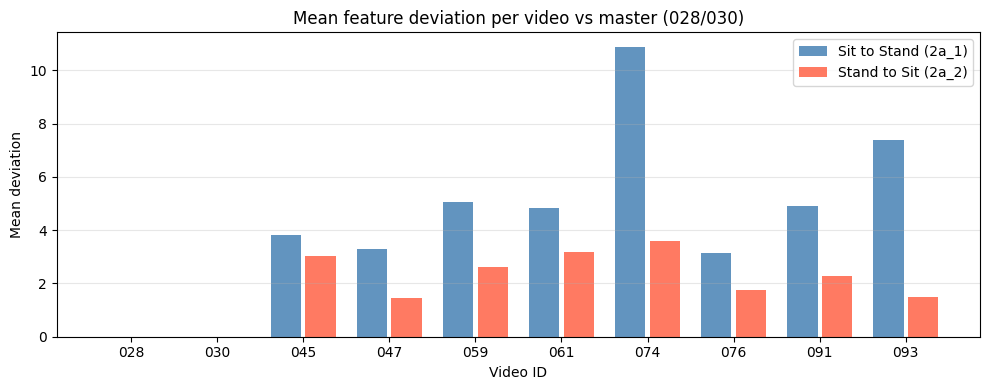

In [61]:
mean_dev = deviations_df.groupby(['video_id','movement'])['deviation'].mean().unstack().round(3)
print('Mean deviation per video:')
print(mean_dev.to_string())

videos = mean_dev.index.astype(str).tolist()
x      = np.arange(len(videos))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, mean_dev['2a_1'], width=0.35, label='Sit to Stand (2a_1)', color='steelblue', alpha=0.85)
ax.bar(x + 0.2, mean_dev['2a_2'], width=0.35, label='Stand to Sit (2a_2)', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(videos)
ax.set_xlabel('Video ID')
ax.set_ylabel('Mean deviation')
ax.set_title('Mean feature deviation per video vs master (028/030)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RQ2_DIR / 'mean_feature_deviation_per_video.png', dpi=300, bbox_inches='tight')
plt.show()



## Step 5: Normalize Deviation Scores

Min-max normalize each feature's deviation across participants, separately for KORS and RAK.

In [62]:
def minmax_norm(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0.0
    return (series - mn) / (mx - mn)

norm_rows = []

for (mvmt, phase, feat_col), group in deviations_df.groupby(['movement', 'phase', 'feature_column']):
    kors_idx = group['video_id'].isin(KORS_VIDEOS)
    rak_idx  = group['video_id'].isin(RAK_VIDEOS)

    norm_vals = pd.Series(index=group.index, dtype=float)
    if kors_idx.sum() > 0:
        norm_vals[kors_idx] = minmax_norm(group.loc[kors_idx, 'deviation']).values
    if rak_idx.sum() > 0:
        norm_vals[rak_idx]  = minmax_norm(group.loc[rak_idx,  'deviation']).values

    for idx, row in group.iterrows():
        norm_rows.append({
            'movement':         row['movement'],
            'phase':            row['phase'],
            'aspect_id':        row['aspect_id'],
            'aspect_name':      row['aspect_name'],
            'video_id':         row['video_id'],
            'feature_column':   row['feature_column'],
            'source':           row['source'],
            'deviation':        row['deviation'],
            'deviation_norm':   round(norm_vals[idx], 4),
        })

deviations_norm_df = pd.DataFrame(norm_rows)

print(f'Rows: {len(deviations_norm_df)}  |  features: {deviations_norm_df["feature_column"].nunique()}  |  videos: {deviations_norm_df["video_id"].nunique()}')
print()
print('Sample (utg_mean_left_knee_angle, f1, 2a_1):')
sample = deviations_norm_df[
    (deviations_norm_df['feature_column'] == 'utg_mean_left_knee_angle') &
    (deviations_norm_df['phase'] == 'f1') &
    (deviations_norm_df['movement'] == '2a_1')
][['video_id', 'deviation', 'deviation_norm']].drop_duplicates(subset=['video_id'])
print(sample.to_string(index=False))

Rows: 670  |  features: 42  |  videos: 10

Sample (utg_mean_left_knee_angle, f1, 2a_1):
video_id  deviation  deviation_norm
     028     0.0000          0.0000
     045     2.2573          0.0877
     059     5.4139          0.2103
     074    25.7396          1.0000
     091     9.7491          0.3788
     030     0.0000          0.0000
     047     0.4194          0.0380
     061     0.3328          0.0302
     076     0.3102          0.0281
     093    11.0291          1.0000


Mean normalised deviation per video:
movement   2a_1   2a_2
video_id              
028       0.000  0.000
030       0.000  0.000
045       0.516  0.580
047       0.503  0.445
059       0.592  0.511
061       0.619  0.714
074       0.831  0.584
076       0.500  0.503
091       0.636  0.503
093       0.774  0.673


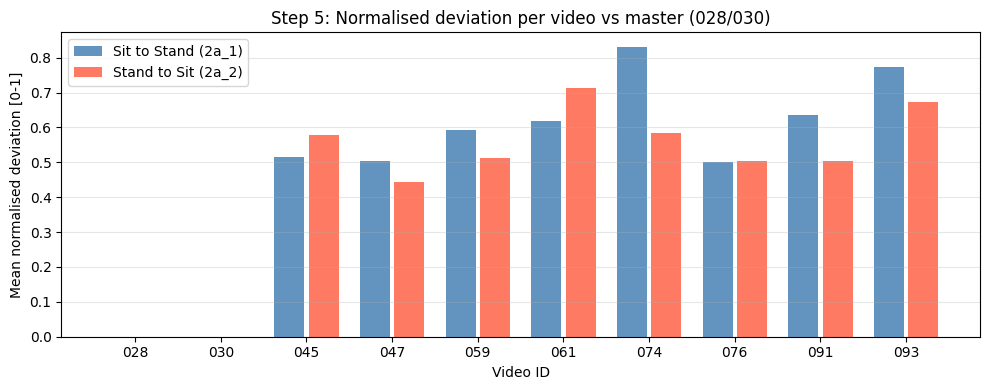

In [63]:
print('Mean normalised deviation per video:')
print(deviations_norm_df.groupby(['video_id','movement'])['deviation_norm'].mean().unstack().round(3).to_string())


mean_norm = deviations_norm_df.groupby(['video_id','movement'])['deviation_norm'].mean().unstack()
videos    = mean_norm.index.astype(str).tolist()
x         = np.arange(len(videos))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, mean_norm['2a_1'], width=0.35, label='Sit to Stand (2a_1)', color='steelblue', alpha=0.85)
ax.bar(x + 0.2, mean_norm['2a_2'], width=0.35, label='Stand to Sit (2a_2)', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(videos)
ax.set_xlabel('Video ID')
ax.set_ylabel('Mean normalised deviation [0-1]')
ax.set_title('Step 5: Normalised deviation per video vs master (028/030)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RQ2_DIR / 'mean_normalised_deviation_per_video.png', dpi=300, bbox_inches='tight')
plt.show()



## Step 6: Aggregate Deviations at Aspect Level

Mean of normalized feature deviations within each aspect and phase, per participant.
Saved to aspect_deviations.csv.

In [64]:
aspect_dev = (
    deviations_norm_df
    .groupby(['movement', 'phase', 'aspect_id', 'aspect_name', 'video_id'])['deviation_norm']
    .mean()
    .reset_index()
    .rename(columns={'deviation_norm': 'aspect_deviation'})
)
aspect_dev['aspect_deviation'] = aspect_dev['aspect_deviation'].round(4)

aspect_dev.to_csv(RQ2_DIR / 'aspect_deviations.csv', index=False)

print(f'aspect_deviations.csv saved  ({len(aspect_dev)} rows, {aspect_dev["aspect_id"].nunique()} aspects, {aspect_dev["video_id"].nunique()} videos)')
print()
print('Sample (aspect 2, f1, 2a_1):')
sample = aspect_dev[
    (aspect_dev['aspect_id'] == 2) &
    (aspect_dev['phase'] == 'f1') &
    (aspect_dev['movement'] == '2a_1')
][['video_id', 'aspect_name', 'aspect_deviation']]
print(sample.to_string(index=False))
print()
print('Mean aspect deviation per video:')
print(aspect_dev.groupby(['video_id', 'movement'])['aspect_deviation'].mean().unstack().round(3).to_string())

aspect_deviations.csv saved  (380 rows, 15 aspects, 10 videos)

Sample (aspect 2, f1, 2a_1):
video_id    aspect_name  aspect_deviation
     028 Knä flex >90gr            0.0000
     030 Knä flex >90gr            0.0000
     045 Knä flex >90gr            0.4017
     047 Knä flex >90gr            0.2352
     059 Knä flex >90gr            0.4998
     061 Knä flex >90gr            0.3179
     074 Knä flex >90gr            1.0000
     076 Knä flex >90gr            0.1502
     091 Knä flex >90gr            0.3721
     093 Knä flex >90gr            1.0000

Mean aspect deviation per video:
movement   2a_1   2a_2
video_id              
028       0.000  0.000
030       0.000  0.000
045       0.555  0.560
047       0.515  0.451
059       0.613  0.504
061       0.659  0.730
074       0.787  0.594
076       0.523  0.473
091       0.643  0.490
093       0.720  0.684


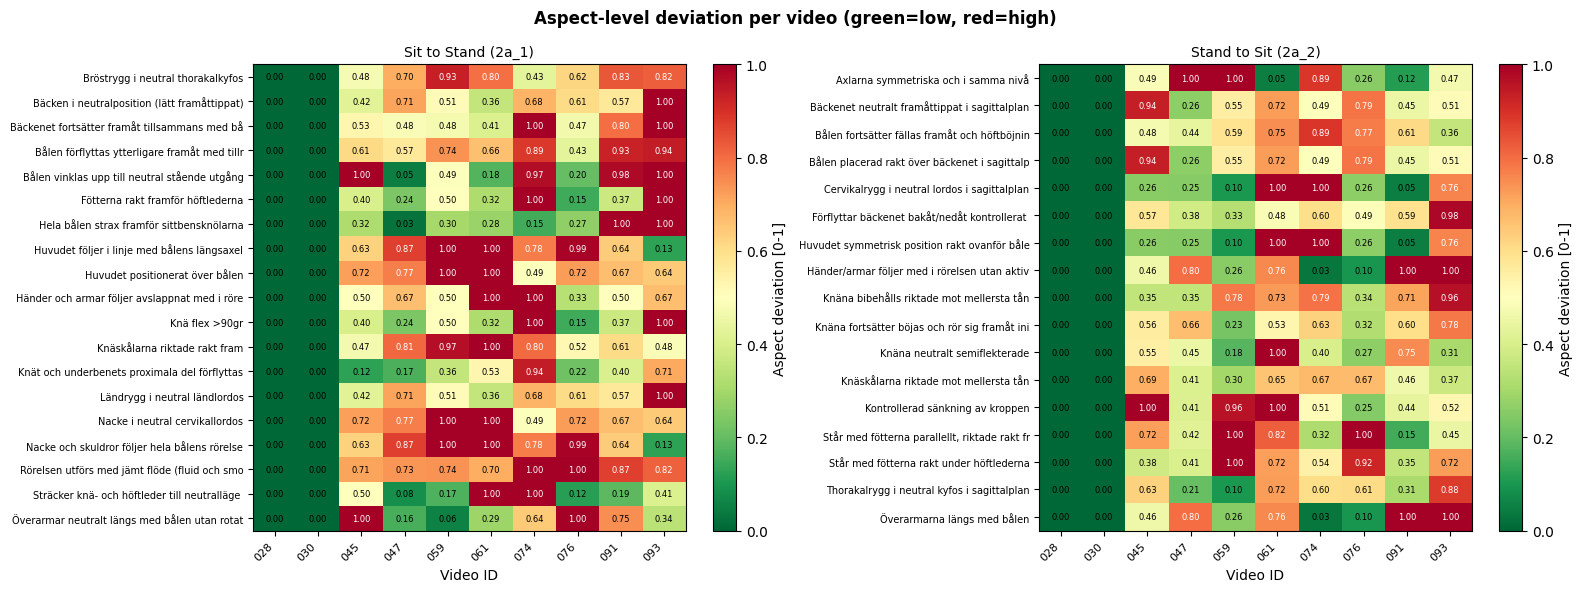

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, mvmt, title in zip(axes, ['2a_1', '2a_2'], ['Sit to Stand', 'Stand to Sit']):
    pivot = (
        aspect_dev[aspect_dev['movement'] == mvmt]
        .groupby(['aspect_name', 'video_id'])['aspect_deviation']
        .mean()
        .unstack('video_id')
        .fillna(0)
    )
    im = ax.imshow(pivot.values, aspect='auto', vmin=0, vmax=1, cmap='RdYlGn_r')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.astype(str), rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([n[:45] for n in pivot.index], fontsize=7)
    ax.set_title(f'{title} ({mvmt})', fontsize=10)
    ax.set_xlabel('Video ID')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            txt_color = 'white' if val >= 0.75 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=txt_color)

    plt.colorbar(im, ax=ax, label='Aspect deviation [0-1]')

plt.suptitle('Aspect-level deviation per video (green=low, red=high)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RQ2_DIR / 'aspect_level_deviation_per_video_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



## Step 7: Correlate Deviations with IRAF Expert Scores

Spearman rank correlation between computed aspect deviation and expert IRAF score (gem_avvikelse).
Small ordinal sample - Spearman is appropriate.

Levels: aspect, phase, movement, participant.

In [66]:
merged = aspect_dev.merge(
    iraf_scores_df[['movement','phase','aspect_id','video_id','gem_avvikelse']],
    on=['movement','phase','aspect_id','video_id'],
    how='inner'
).dropna(subset=['gem_avvikelse','aspect_deviation'])

print(f'Merged rows: {len(merged)}  |  aspects: {merged["aspect_id"].nunique()}  |  videos: {merged["video_id"].nunique()}')

Merged rows: 301  |  aspects: 15  |  videos: 10


In [67]:
asp_rows = []
for (mvmt, phase, aid), grp in merged.groupby(['movement','phase','aspect_id']):
    if len(grp) < 3:
        continue
    r, p = spearmanr(grp['aspect_deviation'], grp['gem_avvikelse'])
    asp_rows.append({'movement':mvmt,'phase':phase,'aspect_id':aid,
                     'aspect_name':grp['aspect_name'].iloc[0],
                     'n':len(grp),'rho':round(r,3),'p':round(p,3)})
asp_corr = pd.DataFrame(asp_rows).sort_values('rho', ascending=False)
asp_corr.to_csv(RQ2_DIR / 'corr_aspect_level.csv', index=False)
print('=== Aspect level ===')
print(asp_corr.to_string(index=False))

=== Aspect level ===
movement phase  aspect_id                                                                            aspect_name  n    rho     p
    2a_2    f3          8                                              Knäna bibehålls riktade mot mellersta tån  4  1.000 0.000
    2a_2    f1         15                                       Bålen placerad rakt över bäckenet i sagittalplan  7  0.879 0.009
    2a_1    f3         10                                 Bålen vinklas upp till neutral stående utgångsposition 10  0.813 0.004
    2a_2    f3          4                                              Knäna bibehålls riktade mot mellersta tån  4  0.800 0.200
    2a_2    f3          3                                    Knäna fortsätter böjas och rör sig framåt initialt. 10  0.766 0.010
    2a_2    f3          2                           Bålen fortsätter fällas framåt och höftböjningen fortskrider 10  0.766 0.010
    2a_2    f1         11                                         Huvudet sy

/var/folders/9k/2kqbhj4s4cnf1w60r_907q940000gn/T/ipykernel_69828/1509413495.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(grp['aspect_deviation'], grp['gem_avvikelse'])


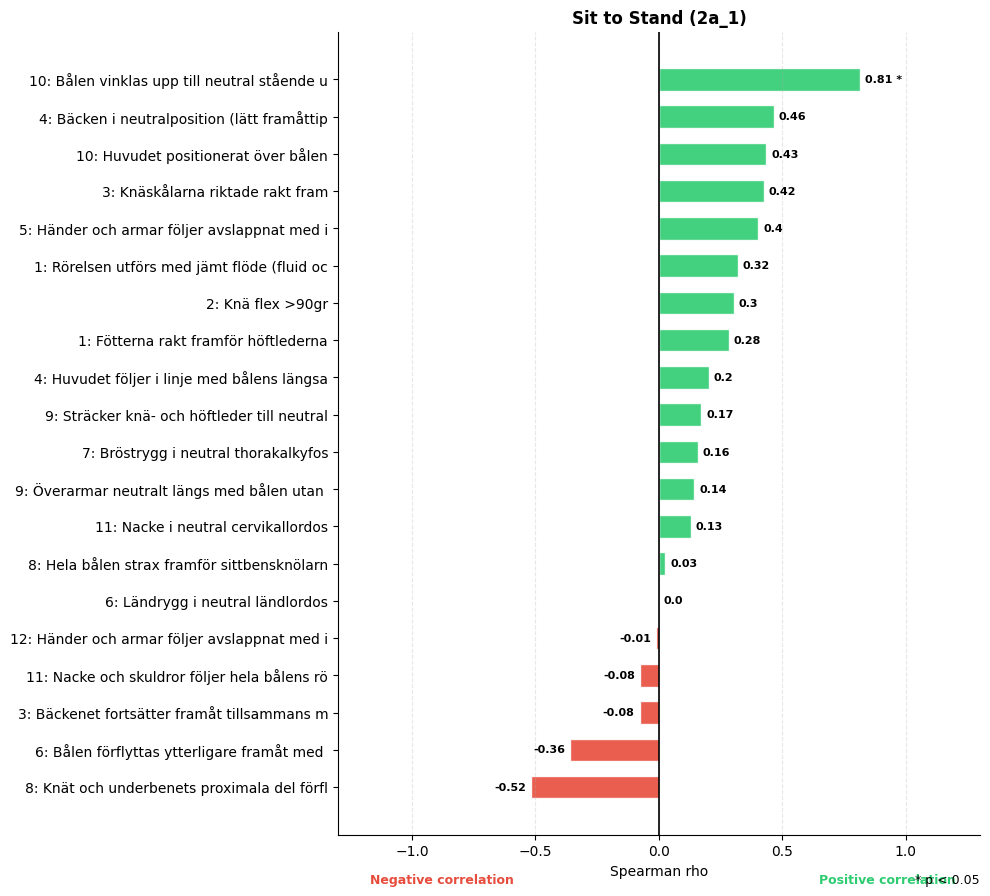

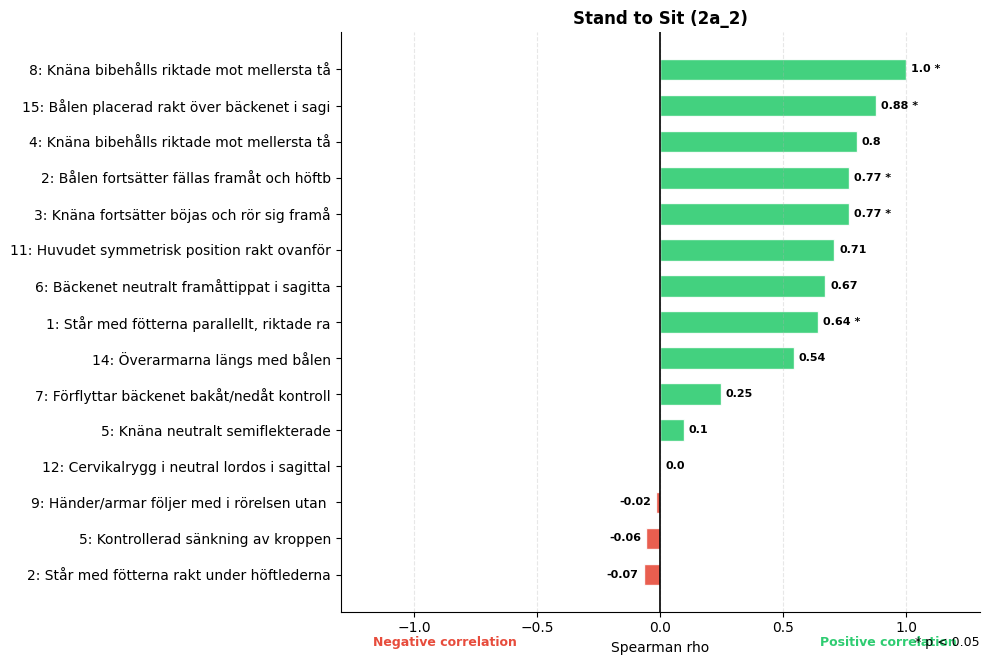

In [68]:
for mvmt, title in [("2a_1", "Sit to Stand (2a_1)"), ("2a_2", "Stand to Sit (2a_2)")]:
    sub = asp_corr[asp_corr["movement"] == mvmt].dropna(subset=["rho"]).sort_values("rho").reset_index(drop=True)
    labels = [str(r.aspect_id) + ": " + r.aspect_name[:40] for r in sub.itertuples()]
    colors = ["#2ecc71" if r.rho >= 0 else "#e74c3c" for r in sub.itertuples()]

    fig, ax = plt.subplots(figsize=(10, max(6, len(sub) * 0.45)))
    bars = ax.barh(labels, sub["rho"], color=colors, alpha=0.9, edgecolor="white", height=0.6)

    for bar, row in zip(bars, sub.itertuples()):
        x = bar.get_width()
        sig = " *" if pd.notna(row.p) and row.p < 0.05 else ""
        ha = "left" if x >= 0 else "right"
        offset = 0.02 if x >= 0 else -0.02
        ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
                str(round(x, 2)) + sig, va="center", ha=ha, fontsize=8, fontweight="bold")

    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_xlabel("Spearman rho")
    ax.set_xlim(-1.3, 1.3)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.text(0.75, -0.06, "Positive correlation", transform=ax.transAxes, fontsize=9, color="#2ecc71", fontweight="bold")
    ax.text(0.05, -0.06, "Negative correlation", transform=ax.transAxes, fontsize=9, color="#e74c3c", fontweight="bold")
    ax.text(1.0, -0.06, "* p < 0.05", transform=ax.transAxes, fontsize=9, ha="right")
    plt.tight_layout()
    plt.savefig(RQ2_DIR / f'corr_aspect_level_bar_{mvmt}.png', dpi=300, bbox_inches='tight')
    plt.show()



In [69]:
phase_rows = []
for (mvmt, phase), grp in merged.groupby(['movement','phase']):
    if len(grp) < 3:
        continue
    r, p = spearmanr(grp['aspect_deviation'], grp['gem_avvikelse'])
    phase_rows.append({'movement':mvmt,'phase':phase,'n':len(grp),'rho':round(r,3),'p':round(p,3)})
phase_corr = pd.DataFrame(phase_rows).sort_values(['movement','phase'])
phase_corr.to_csv(RQ2_DIR / 'corr_phase_level.csv', index=False)
print('=== Phase level ===')
print(phase_corr.to_string(index=False))

=== Phase level ===
movement phase  n   rho     p
    2a_1    f1 85 0.230 0.034
    2a_1    f3 99 0.129 0.202
    2a_2    f1 61 0.326 0.010
    2a_2    f3 56 0.270 0.044


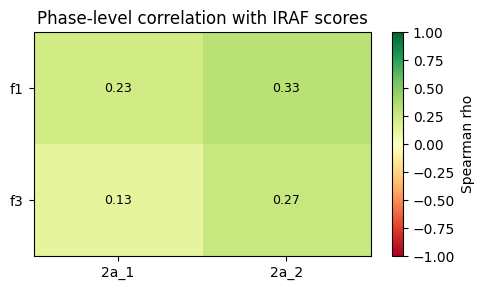

In [70]:
phase_heat = phase_corr.pivot_table(index='phase', columns='movement', values='rho')

fig, ax = plt.subplots(figsize=(5, 3))
im = ax.imshow(phase_heat.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(phase_heat.columns)))
ax.set_xticklabels(phase_heat.columns)
ax.set_yticks(range(len(phase_heat.index)))
ax.set_yticklabels(phase_heat.index)
for i in range(len(phase_heat.index)):
    for j in range(len(phase_heat.columns)):
        val = phase_heat.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color='black')
plt.colorbar(im, ax=ax, label='Spearman rho')
ax.set_title('Phase-level correlation with IRAF scores')
plt.tight_layout()
plt.savefig(RQ2_DIR / 'corr_phase_level_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



In [71]:
mvmt_rows = []
for mvmt, grp in merged.groupby('movement'):
    if len(grp) < 3:
        continue
    r, p = spearmanr(grp['aspect_deviation'], grp['gem_avvikelse'])
    mvmt_rows.append({'movement':mvmt,'n':len(grp),'rho':round(r,3),'p':round(p,3)})
mvmt_corr = pd.DataFrame(mvmt_rows)
mvmt_corr.to_csv(RQ2_DIR / 'corr_movement_level.csv', index=False)
print('=== Movement level ===')
print(mvmt_corr.to_string(index=False))

=== Movement level ===
movement   n   rho     p
    2a_1 184 0.171 0.020
    2a_2 117 0.277 0.002


In [72]:
part_rows = []
for (vid, mvmt), grp in merged.groupby(['video_id', 'movement']):
    if len(grp) < 3:
        continue
    r, p = spearmanr(grp['aspect_deviation'], grp['gem_avvikelse'])
    part_rows.append({'video_id': vid, 'movement': mvmt, 'n': len(grp), 'rho': round(r, 3), 'p': round(p, 3)})
part_corr = pd.DataFrame(part_rows)
part_corr.to_csv(RQ2_DIR / 'corr_participant_level.csv', index=False)

for mvmt, label in [('2a_1', 'Sit to Stand'), ('2a_2', 'Stand to Sit')]:
    sub = part_corr[part_corr['movement'] == mvmt].sort_values('rho', ascending=False)
    print(f'=== Participant level , {label} ({mvmt}) ===')
    print(sub[['video_id','n','rho','p']].to_string(index=False))
    print()

=== Participant level , Sit to Stand (2a_1) ===
video_id  n    rho     p
     047 20  0.198 0.402
     061 19  0.193 0.428
     045 18  0.157 0.534
     059 18  0.120 0.635
     091 19 -0.102 0.677
     076 18 -0.163 0.519
     074 17 -0.393 0.118
     093 19 -0.398 0.091
     028 18    NaN   NaN
     030 18    NaN   NaN

=== Participant level , Stand to Sit (2a_2) ===
video_id  n    rho     p
     093 15  0.331 0.228
     076 13  0.307 0.307
     047 13  0.000 1.000
     091  9 -0.018 0.963
     061 13 -0.108 0.726
     059 10 -0.262 0.465
     074  9 -0.358 0.343
     045 11 -0.429 0.187
     028  8    NaN   NaN
     030 16    NaN   NaN



/var/folders/9k/2kqbhj4s4cnf1w60r_907q940000gn/T/ipykernel_69828/2599255124.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(grp['aspect_deviation'], grp['gem_avvikelse'])


### Participant-level correlation plots

Horizontal bar charts show participant-level Spearman correlation (`rho`) for each movement.


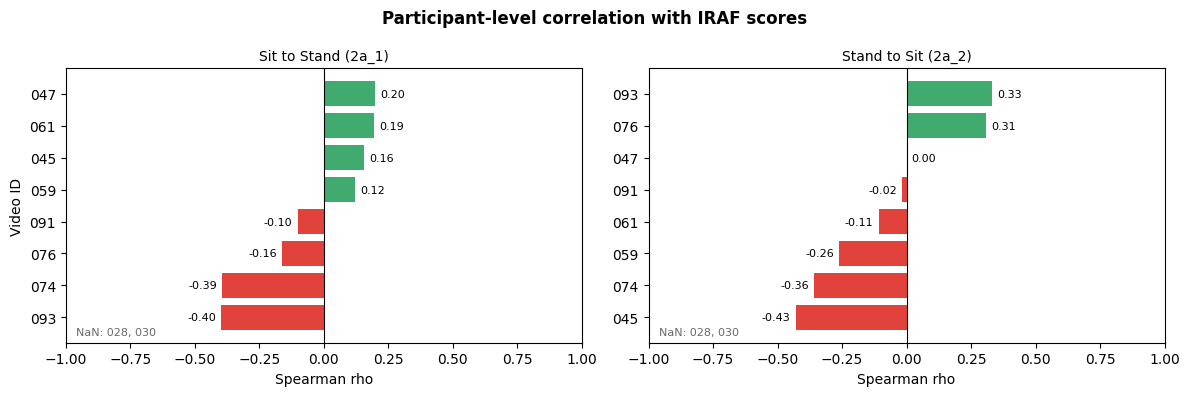

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, (mvmt, label) in zip(axes, [('2a_1', 'Sit to Stand'), ('2a_2', 'Stand to Sit')]):
    sub = part_corr[part_corr['movement'] == mvmt].copy()
    sub = sub.sort_values('rho', ascending=True, na_position='last')

    plot_sub = sub.dropna(subset=['rho']).copy()
    colors = ['#2ca25f' if rho >= 0 else '#de2d26' for rho in plot_sub['rho']]

    ax.barh(plot_sub['video_id'].astype(str), plot_sub['rho'], color=colors, alpha=0.9)
    ax.axvline(0, color='black', linewidth=0.8)

    for y, (_, row) in enumerate(plot_sub.iterrows()):
        rho = row['rho']
        pval = row['p']
        star = ' *' if pd.notna(pval) and pval < 0.05 else ''
        x = rho + 0.02 if rho >= 0 else rho - 0.02
        ha = 'left' if rho >= 0 else 'right'
        ax.text(x, y, f'{rho:.2f}{star}', va='center', ha=ha, fontsize=8)

    nan_videos = sub[sub['rho'].isna()]['video_id'].astype(str).tolist()
    if nan_videos:
        ax.text(0.02, 0.02, f'NaN: {", ".join(nan_videos)}', transform=ax.transAxes,
                fontsize=8, color='dimgray', ha='left', va='bottom')

    ax.set_title(f'{label} ({mvmt})', fontsize=10)
    ax.set_xlabel('Spearman rho')
    ax.set_xlim(-1, 1)

axes[0].set_ylabel('Video ID')
plt.suptitle('Participant-level correlation with IRAF scores', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RQ2_DIR / 'corr_participant_level.png', dpi=300, bbox_inches='tight')
plt.show()



## MAE mot MoLAB och IRAF-korrelation

Jämför medelfel (MAE) i grader mot MoLAB före och efter höftkorrigering

In [74]:
import glob
import numpy as np
import pandas as pd

VIDEO_FPS = 50
VIDEO_ASPECT = 1920 / 1080

mapping = [
    ('0028','Fp1_SB'),('0030','Fp1_SB'),
    ('0045','Fp2_CF'),('0047','Fp2_CF'),
    ('0059','Fp3_JN'),('0061','Fp3_JN'),
    ('0074','Fp4_AL'),('0076','Fp4_AL'),
    ('0091','Fp5_WL'),('0093','Fp5_WL'),
]
beep_times = {'0028':9.14,'0030':5.38,'0045':5.88,'0047':6.12,
              '0059':5.70,'0061':6.10,'0074':5.42,'0076':5.54,
              '0091':5.52,'0093':5.00}
corrections = {'0028':0.52}

PLOT_JOINTS = [
    ('L_knee_X','Left Knee'),('R_knee_X','Right Knee'),
    ('L_hip_X','Left Hip'),  ('R_hip_X', 'Right Hip'),
    ('L_ankle_X','Left Ankle'),('R_ankle_X','Right Ankle'),
    ('pelvis_X','Pelvis'),
]

DIRS = {
    'sit_to_stand': {
        'raw':   '../data/processed/keypoints_combined',
        'corr':  '../data/processed/keypoints_corrected',
        'molab': '../data/processed/molab_cropped',
    },
    'stand_to_sit': {
        'raw':   '../data/processed/keypoints_combined_down',
        'corr':  '../data/processed/keypoints_corrected_down',
        'molab': '../data/processed/molab_cropped_down',
    },
}

def joint_angle_2d(ax,ay,bx,by,cx,cy):
    v1x,v1y=ax-bx,ay-by; v2x,v2y=cx-bx,cy-by
    dot=v1x*v2x+v1y*v2y
    norm=np.sqrt(v1x**2+v1y**2)*np.sqrt(v2x**2+v2y**2)+1e-8
    return 180-np.degrees(np.arccos(np.clip(dot/norm,-1,1)))

def segment_angle_2d(ax,ay,bx,by,cx,cy,dx,dy):
    v1x,v1y=bx-ax,by-ay; v2x,v2y=dx-cx,dy-cy
    dot=v1x*v2x+v1y*v2y
    norm=np.sqrt(v1x**2+v1y**2)*np.sqrt(v2x**2+v2y**2)+1e-8
    return 180-np.degrees(np.arccos(np.clip(dot/norm,-1,1)))

def trunk_angle_2d(kp):
    mid_hip_x=(kp['left_hip_x'].values+kp['right_hip_x'].values)/2
    mid_hip_y=(kp['left_hip_y'].values+kp['right_hip_y'].values)/2
    mid_sh_x=(kp['left_shoulder_x'].values+kp['right_shoulder_x'].values)/2
    mid_sh_y=(kp['left_shoulder_y'].values+kp['right_shoulder_y'].values)/2
    dx=mid_sh_x-mid_hip_x; dy=mid_sh_y-mid_hip_y
    return -np.degrees(np.arctan2(dx,-dy))

def compute_kp_angles(kp):
    kp=kp.copy()
    for c in kp.columns:
        if c.endswith('_x'): kp[c]*=VIDEO_ASPECT
    a={}
    for side,s in [('L','left'),('R','right')]:
        a[f'{side}_knee_X']=joint_angle_2d(
            kp[f'{s}_hip_x'].values,kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,kp[f'{s}_knee_y'].values,
            kp[f'{s}_ankle_x'].values,kp[f'{s}_ankle_y'].values)
        a[f'{side}_hip_X']=joint_angle_2d(
            kp[f'{s}_shoulder_x'].values,kp[f'{s}_shoulder_y'].values,
            kp[f'{s}_hip_x'].values,kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,kp[f'{s}_knee_y'].values)
        a[f'{side}_ankle_X']=segment_angle_2d(
            kp[f'{s}_heel_x'].values,kp[f'{s}_heel_y'].values,
            kp[f'{s}_foot_index_x'].values,kp[f'{s}_foot_index_y'].values,
            kp[f'{s}_ankle_x'].values,kp[f'{s}_ankle_y'].values,
            kp[f'{s}_knee_x'].values,kp[f'{s}_knee_y'].values)
    a['pelvis_X']=trunk_angle_2d(kp)
    return a

def interpolate_to_molab(kp_time, kp_vals, molab_time):
    return np.interp(molab_time, kp_time, kp_vals, left=np.nan, right=np.nan)

offsets={}
for vid,fp in mapping:
    full=pd.read_csv(f'../data/processed/molab/{vid}_molab.csv')
    pre=full[full['molab_frame']<41]
    offsets[vid]={j:pre[f'JointAngle/{j}'].mean() for j,_ in PLOT_JOINTS}

results=[]
for direction, cfg in DIRS.items():
    for vid,fp in mapping:
        molab_f=glob.glob(f"{cfg['molab']}/{vid}_molab.csv")
        raw_f=glob.glob(f"{cfg['raw']}/DJI_*_{vid}_D.csv")
        corr_f=glob.glob(f"{cfg['corr']}/DJI_*_{vid}_D.csv")
        if not(molab_f and raw_f and corr_f): continue
        molab=pd.read_csv(molab_f[0])
        raw=pd.read_csv(raw_f[0]); corr=pd.read_csv(corr_f[0])
        offset=beep_times[vid]-4+corrections.get(vid,0)
        molab_t=molab['molab_time'].values+offset
        mask=molab['molab_frame'].values>=41
        raw_t=raw['frame'].values/VIDEO_FPS
        corr_t=corr['frame'].values/VIDEO_FPS
        raw_a=compute_kp_angles(raw); corr_a=compute_kp_angles(corr)
        for jkey,jlabel in PLOT_JOINTS:
            mv=molab[f'JointAngle/{jkey}'].values.copy()
            mv[mask]+=offsets[vid][jkey]
            t_min=max(molab_t[0],raw_t[0],corr_t[0])
            t_max=min(molab_t[-1],raw_t[-1],corr_t[-1])
            valid=(molab_t>=t_min)&(molab_t<=t_max)
            if valid.sum()<10: continue
            mt=molab_t[valid]; mv2=mv[valid]
            rv=interpolate_to_molab(raw_t,raw_a[jkey],mt)
            cv=interpolate_to_molab(corr_t,corr_a[jkey],mt)
            ok=~np.isnan(rv)&~np.isnan(cv)&~np.isnan(mv2)
            if ok.sum()<5: continue
            results.append({
                'direction':direction,'vid':vid,'fp':fp,'joint':jlabel,
                'mae_raw':np.mean(np.abs(rv[ok]-mv2[ok])),
                'mae_corr':np.mean(np.abs(cv[ok]-mv2[ok])),
            })

df=pd.DataFrame(results)
summary=df.groupby(['direction']).agg(mae_raw=('mae_raw','mean'),mae_corr=('mae_corr','mean')).round(2)
summary['improvement_%']= ((summary['mae_raw']-summary['mae_corr'])/summary['mae_raw']*100).round(1)
summary.index=['Sit-to-stand','Stand-to-sit']
summary.columns=['Ra SAT (deg)','Korrigerat SAT (deg)','Forbattring (%)']
print("=== MAE mot MoLAB: Ra vs Korrigerat ===")
display(summary)

print()
print("=== IRAF-korrelation: Ej korrigerat vs Korrigerat ===")
corr_raw = pd.read_csv('../data/processed/rq2/uncorrected_keypoints/corr_movement_level.csv')
corr_corr = pd.read_csv('../data/processed/rq2/corrected/corr_movement_level.csv')
label_map = {'2a_1': 'Sit-to-stand', '2a_2': 'Stand-to-sit'}
rows = []
for _, r in corr_raw.iterrows():
    c = corr_corr[corr_corr['movement']==r['movement']].iloc[0]
    rows.append({
        'Rorelse': label_map[r['movement']],
        'Rho (ej korr)': round(r['rho'],3),
        'p (ej korr)': round(r['p'],3),
        'Rho (korr)': round(c['rho'],3),
        'p (korr)': round(c['p'],3),
    })
display(pd.DataFrame(rows).set_index('Rorelse'))


=== MAE mot MoLAB: Ra vs Korrigerat ===


,Ra SAT (deg),Korrigerat SAT (deg),Forbattring (%)
Sit-to-stand,12.96,12.96,0.0
Stand-to-sit,12.39,12.39,0.0



=== IRAF-korrelation: Ej korrigerat vs Korrigerat ===


,Rho (ej korr),p (ej korr),Rho (korr),p (korr)
Rorelse,,,,
Sit-to-stand,0.142,0.048,0.171,0.020
Stand-to-sit,0.217,0.014,0.277,0.002
